# Problem 5 - TTA metric, Stability, Generalization 20 points

This question is based on efforts around DL benchmarking and standardization of performance metrics. We will study TTA metric properties using CIFAR10 dataset. Observe that, MLPerf and DAWNBench both use Imagenet1K for benchmarking but we will use CIFAR10, purely for convenience. In particular, we want to study (i) TTA stability, and (ii) Generalization performance of models optimized for TTA. A similar study was done in Coleman et al. using MLPerf and DAWNBench models. You should read this paper (especially Section 4.1 and 4.2) to have a better understanding of what you will be doing in this question. To study stability we will compute the coefficient of variation of TTA on different hardware by running several times the same training job. You will train Resnet-50 model in Pytorch with 2 different hardware types (V100, TPU pod) using CIFAR10. You will use a batch size of 128 and train the model till you get 92% validation accuracy.. From the training logs get the total (wall-clock) time to reach 92% validation accuracy for each of the runs. We need data from at least 5 different training runs for the same configuration. This data collection can be done in a group of 5 students. Each of the student (in a group of 5) can run the same two training jobs, one with V100 and one with a TPU pod. If you decide to collaborate in the data collection please clearly mention the name of students involved in your submission.

**I cooperate with  Aneri Patel (app7533) for the data collection, specifically, I run the model with V100 and Aneri Patel runs the model with RTX8000**

In [3]:
import numpy as np

## 5.1

In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torchvision
from torch.autograd import Variable
import torchvision.transforms as transforms
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU = torch.cuda.get_device_name(0)

BATCH_SIZE = 128
num_epochs = 350
criterion = nn.CrossEntropyLoss()
lr=0.001
momentum=0.9


train_transforms = transforms.Compose(
    [transforms.ToTensor(),transforms.RandomHorizontalFlip(),torchvision.
     transforms.RandomRotation((-15, +15)),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data',train=True, download=True, transform = train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False, num_workers=2)

total_step = len(trainloader)
classes = test_dataset.classes

In [ ]:
for run_no in range(1,6): 
    
    print("run_no: ", run_no)
    
    model = torchvision.models.resnet50(pretrained=True,progress=False).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
               
    f = open(str(run_no)+"_"+GPU+".csv", "w")
    f.write('epoch,acc test,acc train,time\n')
    
    start = time.time()
    for epoch in range(num_epochs):
        correct_train = 0
        total_train = 0
        
        correct = 0
        total =0
        acc = 0
        
        for i, (images, labels) in enumerate(trainloader, 0):
            model.train()
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            predicted=torch.argmax(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            correct_train = correct
            total_train = total
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            
            loss.backward()
            optimizer.step()
            
            if (i) % 100 == 0:
                print ("Epoch [{}/{}], Step [{}/{}] Loss:{:.4f}".format(epoch+1, num_epochs, i+1, total_step, loss.item()))

            # Test the model
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            acc = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted=torch.argmax(outputs,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                acc = 100 * correct / total
            print('Accuracy of the model on the test images: {} %'.format(acc))
            f.write('%d,%.7f,%.7f,%.7f\n' % (epoch + 1, acc, 100*(correct_train*1.0/total_train), time.time() - start))
            
            model.train()
            if acc >=85:
                torch.save(model, "/scratch/app7533/hw5/"+GPU+str(run_no)+".h5")
                break
                
        
        
    end = time.time()
    print(end - start, "seconds")
    f.close()
    print('Finished Training '+ str(run_no))

### Results

In [15]:
pwd

'/home/xiangpan/Labs/NYU_DL_Sys/HW5'

In [20]:
import os
import numpy as np
import pandas as pd

rtx_time_to_reach_acc = []
v100_time_to_reach_acc = []

path = './problem5/'
GPUS = ["Quadro RTX 8000", "TeslaV100-PCIE-32GB"]
for GPU in GPUS:
    for run_no in range(1,6):
        filename = str(run_no)+"_"+ GPU + ".csv"
#         print(filename)
        df = pd.read_csv(path+filename)
        df2 = df[df['acc test'] >= 85]
        print(filename, df2.head(1)['time'].values[0])
        if '100' in filename:
            v100_time_to_reach_acc.append(df2.head(1)['time'].values[0])
        else:
            rtx_time_to_reach_acc.append(df2.head(1)['time'].values[0])
            
var = np.var(rtx_time_to_reach_acc)
mean = np.mean(rtx_time_to_reach_acc)
rtx_coeffient = var/mean

var = np.var(v100_time_to_reach_acc)
mean = np.mean(v100_time_to_reach_acc)
v100_coeffient = var/mean

print(f"Resnet-50 RTX-8000 Coefficient of variation: {rtx_coeffient}%")
print(f"Resnet-50 V100 Coefficient of variation: {v100_coeffient}%")

1_Quadro RTX 8000.csv 231.3998671
2_Quadro RTX 8000.csv 203.1650827
3_Quadro RTX 8000.csv 232.2512333
4_Quadro RTX 8000.csv 203.0370133
5_Quadro RTX 8000.csv 203.2959378
1_TeslaV100-PCIE-32GB.csv 239.3399966
2_TeslaV100-PCIE-32GB.csv 391.7112553
3_TeslaV100-PCIE-32GB.csv 426.8212438
4_TeslaV100-PCIE-32GB.csv 297.8189402
5_TeslaV100-PCIE-32GB.csv 223.2651255
Resnet-50 RTX-8000 Coefficient of variation: 0.9188275042736871%
Resnet-50 V100 Coefficient of variation: 20.78612503426173%


## 5.2

In [10]:
from IPython.display import Markdown, display, Code

display(Code("problem5/test_model.py"))

import os
from torch.utils.data import Dataset
import glob
import cv2
from PIL import Image
import torch

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torchvision
from torch.autograd import Variable
import torchvision.transforms as transforms
import torch.optim as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU = torch.cuda.get_device_name(0)

BATCH_SIZE = 128
num_epochs = 350
criterion = nn.CrossEntropyLoss()
lr=0.001
momentum=0.9

train_transforms = transforms.Compose(
    [transforms.ToTensor(),transforms.RandomHorizontalFlip(),torchvision.
     transforms.RandomRotation((-15, +15)),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

class CustomDataset(Dataset):
    def __init__(self):
    
        self.imgs_path = "./problem5/labeled_images"
        file_list = os.walk(self.imgs_path)

        # print(file_list)
        self.data = []
        self.class_map = {"airplane": 0, "automobile": 1, "bird": 2, "cat" : 3,"deer": 4, "dog": 5, "frog": 6,"horse": 7, "ship": 8, "truck": 9}
        self.class_list = list(self.class_map.keys())


        for c in self.class_list:
            class_path = os.path.join(self.imgs_path, c)
            for img_path in glob.glob(class_path + "/*.jpg"):
                self.data.append((img_path, c))

        
        self.img_dim = (32, 32)
    
    def __len__(self): 
        return len(self.data)
    
    def __getitem__(self, idx):
        
        img_path, class_name = self.data[idx]
        img = Image.open(img_path)
        class_id = self.class_map[class_name]
        img = test_transforms(img)
        class_id = torch.tensor(class_id)
        
        return img, class_id


wild_dataset = CustomDataset()
test_loader = torch.utils.data.DataLoader(dataset=wild_dataset,batch_size=BATCH_SIZE)

v100_acc = []
rtx_acc = []
GPUS = ["problem5/Tesla V100-PCIE-32GB"]

for GPU in GPUS:
    for run_no in range(1,6):
        filename = GPU+str(run_no)+".h5"
        print(f'Model: {filename}')
        model = torch.load(filename)
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            acc = 0
            for images, labels in test_loader:
                images = images.cuda()
                labels = labels.cuda()
                outputs = model(images)
                predicted=torch.argmax(outputs,1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                acc = 100 * correct / total
                if '100' in filename.lower():
                    v100_acc.append(acc)
                else:
                    rtx_acc.append(acc)

            print("Total Images:", total, "Correctly classified: ", correct)
            print('Accuracy of the model on the test images: {} %'.format(acc))
            print()

### V100

Model: problem5/Tesla V100-PCIE-32GB1.h5
Total Images: 40 Correctly classified:  31
Accuracy of the model on the test images: 77.
5 %

Model: problem5/Tesla V100-PCIE-32GB2.h5
Total Images: 40 Correctly classified:  29
Accuracy of the model on the test images: 72.5 %

Model: problem5/Tesla V100-PCIE-32GB3.h5
Total Images: 40 Correctly classified:  31
Accuracy of the model on the test images: 77.5 %

Model: problem5/Tesla V100-PCIE-32GB4.h5
Total Images: 40 Correctly classified:  30
Accuracy of the model on the test images: 75.0 %

Model: problem5/Tesla V100-PCIE-32GB5.h5
Total Images: 40 Correctly classified:  30
Accuracy of the model on the test images: 75.0 %

In [4]:
import numpy as np
v100_test_accuracy = [77.5, 72.5, 77.5, 75.0, 75.0]
v100_test_accuracy = np.array(v100_test_accuracy)/100

In [5]:

v100_acc_mean = np.mean(v100_test_accuracy)
v100_acc_std = np.std(v100_test_accuracy)

In [6]:
v100_acc_mean, v100_acc_std

(0.755, 0.018708286933869726)

### RTX8000

Model: Quadro RTX 80001.h5
Total Images: 50 Correctly classified:  40
Accuracy of the model on the test images: 80.0 %

Model: Quadro RTX 80002.h5
Total Images: 50 Correctly classified:  38
Accuracy of the model on the test images: 76.0 %

Model: Quadro RTX 80003.h5
Total Images: 50 Correctly classified:  39
Accuracy of the model on the test images: 78.0 %

Model: Quadro RTX 80004.h5
Total Images: 50 Correctly classified:  36
Accuracy of the model on the test images: 72.0 %

Model: Quadro RTX 80005.h5
Total Images: 50 Correctly classified:  38
Accuracy of the model on the test images: 76.0 %

In [7]:
rtx_test_accuracy = [80.0, 76.0, 78.0, 72.0, 76.0]
rtx_test_accuracy = np.array(rtx_test_accuracy)/100

In [8]:
rtx_acc_mean = np.mean(rtx_test_accuracy)
rtx_acc_std = np.std(rtx_test_accuracy)

In [9]:
rtx_acc_mean, rtx_acc_std

(0.7639999999999999, 0.026532998322843223)

## 5.3

In [12]:
from IPython.display import Markdown, display, Code

display(Code("problem5/q5.py"))

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torchvision
from torch.autograd import Variable
import torchvision.transforms as transforms
import torch.optim as optim

torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU = torch.cuda.get_device_name(0)

BATCH_SIZE = 128
num_epochs = 350
criterion = nn.CrossEntropyLoss()
lr=0.001
momentum=0.9


train_transforms = transforms.Compose(
    [transforms.ToTensor(),transforms.RandomHorizontalFlip(),torchvision.
     transforms.RandomRotation((-15, +15)),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./cached_datasets',train=True, download=True, transform = train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='./cached_datasets', train=False, download=True, transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False, num_workers=2)

total_step = len(trainloader)
classes = test_dataset.classes

for run_no in range(1,6): 
    
    print("run_no: ", run_no)
    
    model = torchvision.models.resnet50(pretrained=True,progress=False).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
               
    f = open(str(run_no)+"_"+GPU+".csv", "w")
    f.write('epoch,acc test,acc train,time\n')
    
    start = time.time()
    for epoch in range(num_epochs):
        correct_train = 0
        total_train = 0
        
        correct = 0
        total =0
        acc = 0
        
        for i, (images, labels) in enumerate(trainloader, 0):
            model.train()
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            predicted=torch.argmax(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            correct_train = correct
            total_train = total
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            
            loss.backward()
            optimizer.step()
            
            if (i) % 100 == 0:
                print ("Epoch [{}/{}], Step [{}/{}] Loss:{:.4f}".format(epoch+1, num_epochs, i+1, total_step, loss.item()))

            # Test the model
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            acc = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted=torch.argmax(outputs,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                acc = 100 * correct / total
            print('Accuracy of the model on the test images: {} %'.format(acc))
            f.write('%d,%.7f,%.7f,%.7f\n' % (epoch + 1, acc, 100*(correct_train*1.0/total_train), time.time() - start))
            
            model.train()
            if acc >=85:
                torch.save(model, "./problem5/"+GPU+str(run_no)+".h5")
                break
                
        
        
    end = time.time()
    print(end - start, "seconds")
    f.close()
    print('Finished Training '+ str(run_no))

```
nvidia-smi dmon -i 0 -s mu -d 5 -o TD
#Date       Time        gpu    fb  bar1    sm   mem   enc   dec
#YYYYMMDD   HH:MM:SS    Idx    MB    MB     %     %     %     %
 20220506   23:48:26      0   435    50     1     0     0     0
 20220506   23:48:31      0  1891    50    61    17     0     0
 20220506   23:48:36      0  1891    50    67    19     0     0
 20220506   23:48:41      0  1891    50    58    16     0     0
 20220506   23:48:46      0  1891    50    63    17     0     0
 20220506   23:48:51      0  1891    50    63    18     0     0
 20220506   23:48:56      0  1891    50    68    19     0     0
 20220506   23:49:01      0  1891    50    62    17     0     0
 20220506   23:49:06      0  1891    50    64     9     0     0
 20220506   23:49:11      0  1891    50    61    17     0     0
 20220506   23:49:16      0  1891    50    63    18     0     0
 20220506   23:49:21      0  1891    50    63    18     0     0
 20220506   23:49:26      0  1891    50    62    18     0     0
 20220506   23:49:31      0  1891    50    61    17     0     0
 20220506   23:49:36      0  1891    50    65    18     0     0
 20220506   23:49:41      0  1891    50    58    16     0     0
 20220506   23:49:46      0  1891    50    62    17     0     0
 20220506   23:49:51      0  1891    50    64    17     0     0
 20220506   23:49:56      0  1891    50    59    16     0     0
 20220506   23:50:01      0  1891    50    60     8     0     0
 20220506   23:50:06      0  1891    50    63    18     0     0
 20220506   23:50:11      0  1891    50    69    20     0     0
 20220506   23:50:16      0  1891    50    60    17     0     0
 20220506   23:50:21      0  1891    50    62    17     0     0
 20220506   23:50:26      0  1891    50    56    16     0     0
 20220506   23:50:31      0  1891    50    62    18     0     0
 20220506   23:50:36      0  1891    50    66    18     0     0
 20220506   23:50:41      0  1891    50    52    14     0     0
 20220506   23:50:46      0  1891    50    58    16     0     0
 20220506   23:50:51      0  1891    50    63    18     0     0
 20220506   23:50:56      0  1891    50    69    10     0     0
 20220506   23:51:01      0  1891    50    62    18     0     0
 20220506   23:51:06      0  1891    50    64    18     0     0
 20220506   23:51:12      0  1891    50    54    16     0     0
 20220506   23:51:17      0  1891    50    63    18     0     0
 20220506   23:51:22      0  1891    50    62    17     0     0
 20220506   23:51:27      0  1891    50    53    14     0     0
 20220506   23:51:32      0  1891    50    61    17     0     0
 20220506   23:51:37      0  1891    50    62    17     0     0
 20220506   23:51:42      0  1891    50    63    18     0     0
 20220506   23:51:47      0  1891    50    62    17     0     0
 20220506   23:51:52      0  1891    50    64     9     0     0
 20220506   23:51:57      0  1891    50    53    15     0     0
 ```

Text(0.5, 1.0, 'GPU Utilization Ori')

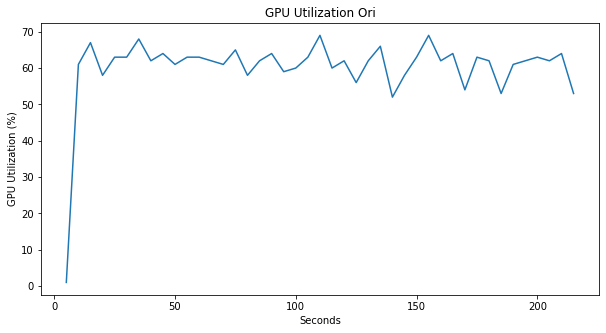

In [33]:
gpu_utilization = [1,61,67,58,63,63,68,62,64,61,63,63,62,61,65,58,62,64,59,60,63,69,60,62,56,62,66,52,58,63,69,62,64,54,63,62,53,61,62,63,62,64,53]
x_list = np.arange(5,5*(len(gpu_utilization)+1), 5)
# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(x_list,gpu_utilization)
plt.xlabel("Seconds")
plt.ylabel("GPU Utilization (%)")
plt.title("GPU Utilization Ori")

```
nvidia-smi dmon -i 0 -s mu -d 5 -o TD
#Date       Time        gpu    fb  bar1    sm   mem   enc   dec
#YYYYMMDD   HH:MM:SS    Idx    MB    MB     %     %     %     %
 20220506   23:56:09      0  1211    50     0     0     0     0
 20220506   23:56:14      0  4291    50    98    37     0     0
 20220506   23:56:19      0  4291    50     0     0     0     0
 20220506   23:56:24      0  4291    50    99    38     0     0
 20220506   23:56:29      0  4291    50    99    38     0     0
 20220506   23:56:34      0  4291    50    99    39     0     0
 20220506   23:56:39      0  4291    50    99    39     0     0
 20220506   23:56:44      0  4291    50     0     0     0     0
 20220506   23:56:49      0  4291    50    99    39     0     0
 20220506   23:56:54      0  4291    50     0     0     0     0
 20220506   23:56:59      0  4291    50    99    39     0     0
 20220506   23:57:04      0  4291    50    99    38     0     0
 20220506   23:57:10      0  4291    50    99    39     0     0
 20220506   23:57:15      0  4291    50    99    38     0     0
 20220506   23:57:20      0  4291    50     0     0     0     0
 20220506   23:57:25      0  4291    50    99    38     0     0
 20220506   23:57:30      0  4291    50    99    28     0     0
 20220506   23:57:35      0  4291    50   100    39     0     0
 20220506   23:57:40      0  4291    50    99    39     0     0
 20220506   23:57:45      0  4291    50    99    38     0     0
 20220506   23:57:50      0  4291    50    99    39     0     0
 20220506   23:57:55      0  4291    50     9     7     0     0
 20220506   23:58:00      0  4291    50    99    39     0     0
 20220506   23:58:05      0  4291    50   100    25     0     0
 20220506   23:58:10      0  4291    50    99    39     0     0
 20220506   23:58:15      0  4291    50    53    19     0     0
 20220506   23:58:20      0  4291    50    99    39     0     0
 20220506   23:58:25      0  4291    50    99    39     0     0
 20220506   23:58:30      0  4291    50    98    38     0     0
 20220506   23:58:35      0  4291    50    99    37     0     0
 20220506   23:58:40      0  4291    50    39     8     0     0
 20220506   23:58:45      0  4291    50    97    38     0     0
 20220506   23:58:50      0  4291    50     0     0     0     0
 20220506   23:58:55      0  4291    50    98    38     0     0
 20220506   23:59:00      0  4291    50    99    38     0     0
 20220506   23:59:05      0  4291    50    99    39     0     0
 20220506   23:59:10      0  4291    50    99    38     0     0
```

## 5.4

We can increase the num_workers to larger number (e.g. 10) and incerase the batch_size to larger number (e.g. 1024) and set pin_memory to True. All those tricks will increase the utilization of GPU computing resources.

In [11]:
from IPython.display import Markdown, display, Code

display(Code("problem5/q5_with_trick.py"))

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torchvision
from torch.autograd import Variable
import torchvision.transforms as transforms
import torch.optim as optim

torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU = torch.cuda.get_device_name(0)

BATCH_SIZE = 1024
num_epochs = 350
criterion = nn.CrossEntropyLoss()
lr=0.001
momentum=0.9


train_transforms = transforms.Compose(
    [transforms.ToTensor(),transforms.RandomHorizontalFlip(),torchvision.
     transforms.RandomRotation((-15, +15)),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./cached_datasets',train=True, download=True, transform = train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='./cached_datasets', train=False, download=True, transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True, num_workers=8, pin_memory=True)
testloader = torch.utils.data.DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False, num_workers=8, pin_memory=True)

total_step = len(trainloader)
classes = test_dataset.classes

for run_no in range(1,6): 
    
    print("run_no: ", run_no)
    
    model = torchvision.models.resnet50(pretrained=True,progress=False).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
               
    f = open(str(run_no)+"_"+GPU+".csv", "w")
    f.write('epoch,acc test,acc train,time\n')
    
    start = time.time()
    for epoch in range(num_epochs):
        correct_train = 0
        total_train = 0
        
        correct = 0
        total =0
        acc = 0
        
        for i, (images, labels) in enumerate(trainloader, 0):
            model.train()
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            predicted=torch.argmax(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            correct_train = correct
            total_train = total
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            
            loss.backward()
            optimizer.step()
            
            if (i) % 100 == 0:
                print ("Epoch [{}/{}], Step [{}/{}] Loss:{:.4f}".format(epoch+1, num_epochs, i+1, total_step, loss.item()))

            # Test the model
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            acc = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted=torch.argmax(outputs,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                acc = 100 * correct / total
            print('Accuracy of the model on the test images: {} %'.format(acc))
            f.write('%d,%.7f,%.7f,%.7f\n' % (epoch + 1, acc, 100*(correct_train*1.0/total_train), time.time() - start))
            
            model.train()
            if acc >=85:
                torch.save(model, "./problem5/"+GPU+str(run_no)+".h5")
                break
                
        
        
    end = time.time()
    print(end - start, "seconds")
    f.close()
    print('Finished Training '+ str(run_no))

Text(0.5, 1.0, 'GPU Utilization Trick')

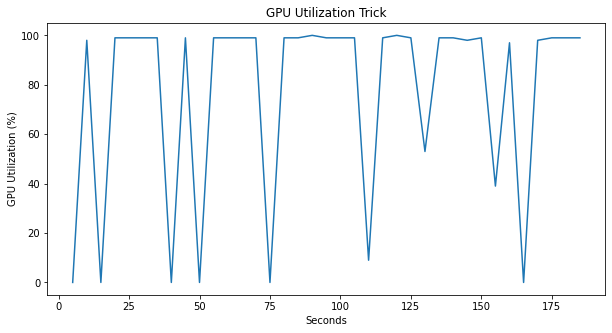

In [34]:
gpu_utilization = [0,98,0,99,99,99,99,0,99,0,99,99,99,99,0,99,99,100,99,99,99,9,99,100,99,53,99,99,98,99,39,97,0,98,99,99,99]
x_list = np.arange(5,5*(len(gpu_utilization)+1), 5)
# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(x_list,gpu_utilization)
plt.xlabel("Seconds")
plt.ylabel("GPU Utilization (%)")
plt.title("GPU Utilization Trick")

The curve is not smooth in that larger batch size makes the data loader for the next epochs, the preparation time is the valley in the curve.